Bibliotecas

In [2]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

Acesso ao Banco

In [3]:
user = 'looqbox-challenge'
password = 'looq-challenge'
host = '35.199.115.174'
database = 'looqbox-challenge'

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{database}")

### Cases

#### 1) The Dev Team was tired of developing the same old queries just varying the filters accordingly to their boss demands.

In [51]:
def pegar_data(product_code, store_code, date):
    query = f"""
        SELECT *
        FROM data_product_sales
        WHERE product_code = {product_code}
        AND store_code = {store_code}
        AND date BETWEEN '{date[0]}' AND '{date[1]}'
    """
    return pd.read_sql(query, engine)

In [52]:
my_data = pegar_data(product_code=18, store_code=1, date=['2019-01-01', '2019-01-31'])
my_data

,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,18,2019-01-01,708.5,65.0
1,1,18,2019-01-02,1297.1,119.0
2,1,18,2019-01-03,1144.5,105.0
3,1,18,2019-01-04,1090.0,100.0
4,1,18,2019-01-05,893.8,82.0
5,1,18,2019-01-06,741.2,68.0
6,1,18,2019-01-07,654.0,60.0
7,1,18,2019-01-08,741.2,68.0
8,1,18,2019-01-09,1373.4,126.0
9,1,18,2019-01-10,1068.2,98.0


#### 2) A brand new client sent you two ready-to-go queries. Those are listed below:

In [17]:
query1 = """
SELECT
        STORE_CODE,
        STORE_NAME,
        START_DATE,
        END_DATE,
        BUSINESS_NAME,
        BUSINESS_CODE
FROM data_store_cad
"""

query2 = """
SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
"""

In [18]:
df_cad   = pd.read_sql(query1, engine)
df_sales = pd.read_sql(query2, engine)

In [24]:
df_merged = pd.merge(df_cad, df_sales, on='STORE_CODE')

In [26]:
df_merged['DATE'] = pd.to_datetime(df_merged['DATE'])

In [27]:
periodo_out_dez = (df_merged['DATE'] >= '2019-10-01') & (df_merged['DATE'] <= '2019-12-31')
df_final = df_merged.loc[periodo_out_dez].copy()

In [28]:
df_final['TM'] = df_final['SALES_VALUE'] / df_final['SALES_QTY']

In [30]:
visualizacao = df_final.groupby(['STORE_NAME', 'BUSINESS_NAME'])['TM'].mean().reset_index()

In [31]:
visualizacao.columns = ['Loja', 'Categoria', 'TM']

In [33]:
visualizacao['TM'] = visualizacao['TM'].round(2)

In [34]:
visualizacao.head(15)

,Loja,Categoria,TM
0,Bahia,Atacado,15.39
1,Bangkok,Posto,13.67
2,Belem,Proximidade,15.37
3,Berlin,Proximidade,15.39
4,Buenos Aires,Atacado,15.39
5,Chicago,Varejo,15.53
6,Dubai,Atacado,15.39
7,Hong Kong,Farma,26.35
8,London,Farma,28.99
9,Madri,Farma,29.03


#### 3) Building your own visualization

In [38]:
df_descobrir = pd.read_sql("SELECT * FROM IMDB_movies LIMIT 1", engine)
print(df_descobrir.columns.tolist())

['Id', 'Title', 'Genre', 'Director', 'Actors', 'Year', 'Runtime', 'Rating', 'Votes', 'RevenueMillions', 'Metascore']


In [39]:
query_imdb = "SELECT Genre, Rating FROM IMDB_movies"
df_imdb = pd.read_sql(query_imdb, engine)

In [46]:
df_imdb['Genre'] = df_imdb['Genre'].str.split(',').str[0]

In [47]:
df_rating = df_imdb.groupby('Genre')['Rating'].mean().sort_values(ascending=False).reset_index()

In [48]:
df_top10 = df_rating.head(10)

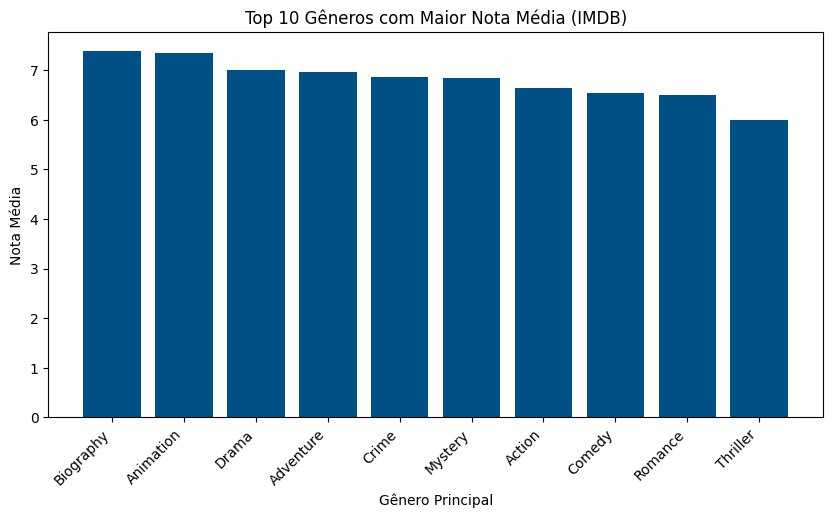

In [49]:
plt.figure(figsize=(10, 5))
plt.bar(df_top10['Genre'], df_top10['Rating'], color='#005088') # Um azul mais profissional
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Gêneros com Maior Nota Média (IMDB)')
plt.xlabel('Gênero Principal')
plt.ylabel('Nota Média')

plt.show()